In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.patches import FancyArrowPatch
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 9
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})


In [51]:
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d.axes3d import Axes3D


def _cone_tris(tip, base_center, radius, n=24):
    tip = np.asarray(tip, float)
    base_center = np.asarray(base_center, float)
    axis = tip - base_center
    L = np.linalg.norm(axis)
    if L == 0:
        return []
    d = axis / L
    ref = np.array([0.0, 0.0, 1.0]) if abs(d[2]) < 0.9 else np.array([1.0, 0.0, 0.0])
    u = np.cross(d, ref); u /= np.linalg.norm(u)
    w = np.cross(d, u)

    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    ring = (base_center[None, :]
            + radius * np.cos(theta)[:, None] * u[None, :]
            + radius * np.sin(theta)[:, None] * w[None, :])

    tris = []
    for i in range(n):
        tris.append([tip, ring[i], ring[(i + 1) % n]])
    for i in range(n):
        tris.append([base_center, ring[(i + 1) % n], ring[i]])
    return tris


def quiver_cone(ax,
                X, Y, Z, U, V, W,
                length=1.0,
                normalize=False,
                color="k",
                linewidth=1.0,
                headlength=0.1,
                headwidth=0.05,
                arrow_length_ratio=None,   # accepted for compat, ignored
                pivot="tail",
                length_includes_head=True,
                n_cone=24,
                **kwargs):
    """
    Quiver-like 3D arrow with a real cone head.

    (X,Y,Z) : start point
    (U,V,W) : VECTOR — arrow goes from (X,Y,Z) to (X+U, Y+V, Z+W)
    """
    X = np.atleast_1d(np.asarray(X, float))
    Y = np.atleast_1d(np.asarray(Y, float))
    Z = np.atleast_1d(np.asarray(Z, float))
    U = np.atleast_1d(np.asarray(U, float))
    V = np.atleast_1d(np.asarray(V, float))
    W = np.atleast_1d(np.asarray(W, float))

    starts = np.column_stack([X, Y, Z])
    vecs   = np.column_stack([U, V, W])   # <-- VECTOR, not endpoint

    if normalize:
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        vecs = vecs / norms * length
    else:
        vecs = vecs * length

    azim = np.deg2rad(ax.azim)
    elev = np.deg2rad(ax.elev)
    cam = np.array([np.cos(elev) * np.cos(azim),
                    np.cos(elev) * np.sin(azim),
                    np.sin(elev)])

    n = len(starts)
    depths = np.empty(n)
    for i in range(n):
        P0 = starts[i]
        V_ = vecs[i]
        if   pivot == "tail":   mid = P0 + 0.5 * V_
        elif pivot == "middle": mid = P0
        elif pivot == "tip":    mid = P0 - 0.5 * V_
        else: raise ValueError("pivot must be 'tail', 'middle', or 'tip'")
        depths[i] = np.dot(mid, cam)
    order = np.argsort(depths)   # farthest first

    for i in order:
        P0 = starts[i]
        V_ = vecs[i]
        L = np.linalg.norm(V_)
        if L == 0:
            continue
        d = V_ / L

        if   pivot == "tail":   tail = P0
        elif pivot == "middle": tail = P0 - 0.5 * V_
        elif pivot == "tip":    tail = P0 - V_
        tip_full = tail + V_

        if length_includes_head:
            tip         = tip_full
            base_center = tip_full - headlength * d
            line_end    = base_center
        else:
            base_center = tip_full
            tip         = tip_full + headlength * d
            line_end    = tip_full

        z = 100 + depths[i]

        if headlength < L:
            ax.plot([tail[0], line_end[0]],
                    [tail[1], line_end[1]],
                    [tail[2], line_end[2]],
                    color=color, linewidth=linewidth,
                    solid_capstyle="round",
                    zorder=z)

        tris = _cone_tris(tip, base_center, headwidth, n=n_cone)
        if tris:
            poly = Poly3DCollection(tris,
                                    facecolors=color,
                                    edgecolor=color,
                                    linewidths=0.1,
                                    zorder=z + 0.5,
                                    shade=True)
            ax.add_collection3d(poly)


Axes3D.quiver_cone = quiver_cone

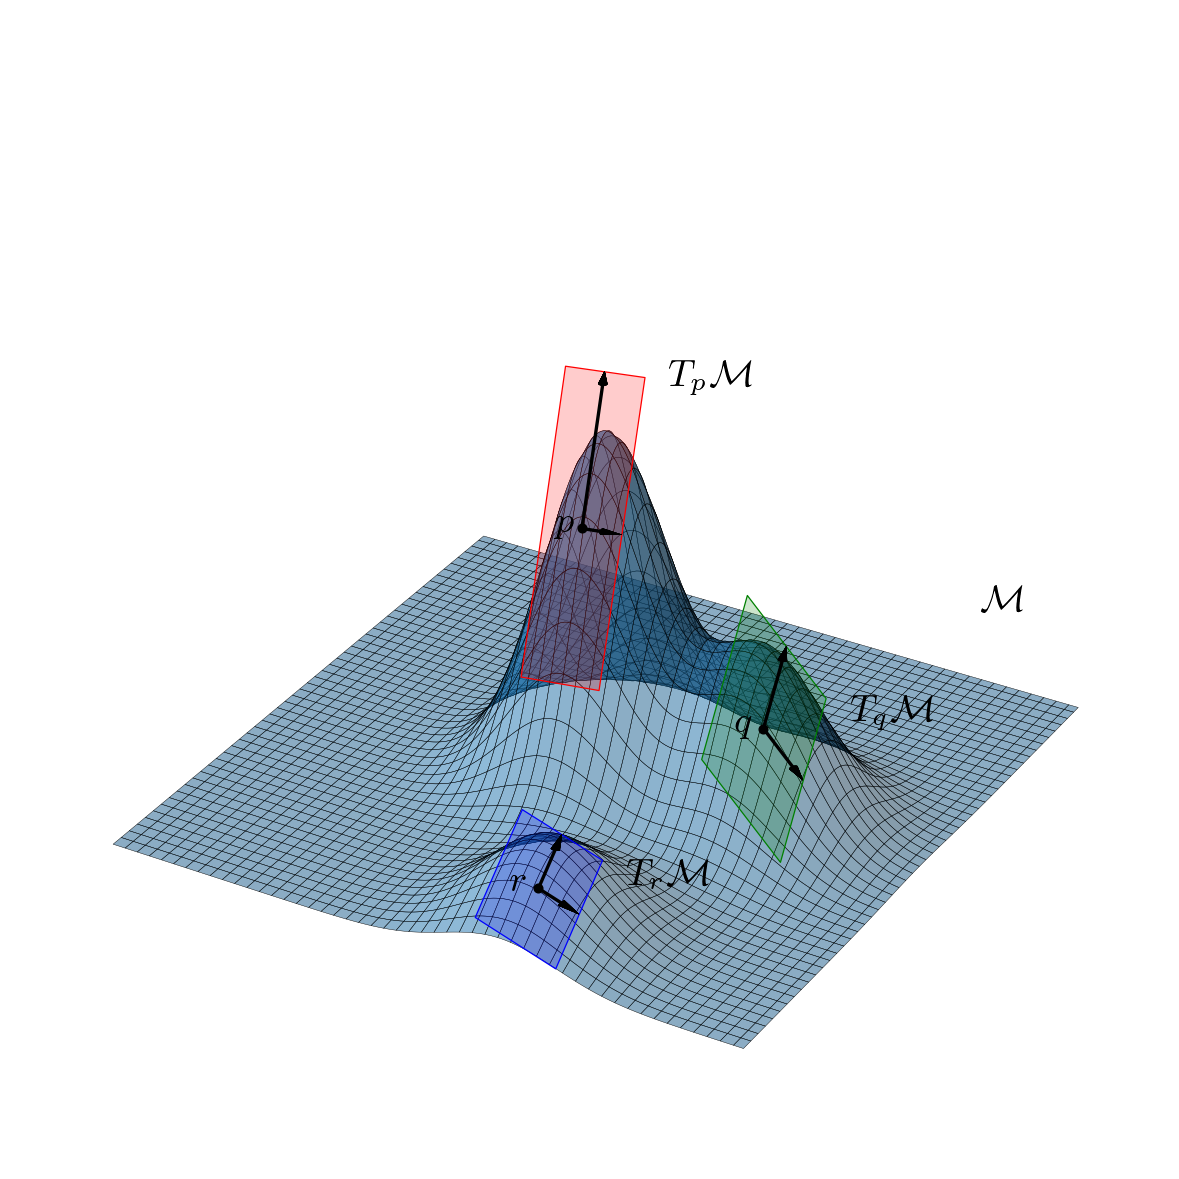

In [89]:
lims = (-4, 4)
x = np.linspace(*lims, 200)
y = np.linspace(*lims, 200)

vx, vy = np.meshgrid(x, y)

def func(x, y):
    r = np.sqrt(x**2 + y**2)
    f = (
        np.exp(-r**2)
        + 0.5 * np.exp(-(x - 2)**2 - y**2)
        + 0.25 * np.exp(-(x - 1)**2 - (y + 3)**2)
    )
    return 8*f

S = func(vx, vy)

p = np.array([0,-0.5])
q = np.array([2.3, -0.5])
r = np.array([1.2,-3.5])

fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

ax.plot_surface(
    vx, vy, S,
    linewidth=0.1,
    edgecolor="black",
    antialiased=True,
    alpha=0.5,
    zorder = 1
)

color_map = {"p": "r", "q": "g", "r": "b"}
names = ["p", "q", "r"]

for name, point in zip(names, (p, q, r)):
    x0, y0 = point
    z0 = func(x0, y0)
    pt = (x0, y0, z0)

    ax.scatter(*pt, color="black", s=2, depthshade=False, zorder=7)

    h = 1e-4
    dfx = (func(x0 + h, y0) - func(x0 - h, y0)) / (2 * h)
    dfy = (func(x0, y0 + h) - func(x0, y0 - h)) / (2 * h)

    tx = np.array([1.0, 0.0, dfx])
    ty = np.array([0.0, 1.0, dfy])

    scale = 0.5
    ex = scale * tx
    ey = scale * ty

    # --- parallelogram patch ---
    origin = np.array(pt)
    corners = np.array([origin + ex + ey, origin + ex - ey, origin - ex - ey, origin - ex + ey])
    plane = Poly3DCollection(
        [corners],
        facecolors=color_map[name],
        edgecolors=color_map[name],
        linewidths=0.3,
        alpha=0.2,
        zorder=6,
        shade=False,
    )
    ax.add_collection3d(plane)

    # --- cone arrows ---
    ax.quiver_cone(*pt, *ex, color="k", linewidth=0.8,
                   headlength=0.25, headwidth=0.05, zorder=8)
    ax.quiver_cone(*pt, *ey, color="k", linewidth=0.8,
                   headlength=0.25, headwidth=0.05, zorder=8)

    ptlabel = pt + np.array([-0.25,0,0])
    spacelabel = pt + 1.1* scale *(tx + ty) + np.array([0.75,0,0])
    ax.text(*ptlabel, rf'${name}$', ha='center', va='center', zorder = 10)
    ax.text(*spacelabel, rf'$T_{name}\mathcal{{M}}$', ha='center', va='center')

ax.text(*[3,4,2], r'$\mathcal{M}$', ha='center', va='center')

ax.set_xlim(lims)
ax.set_ylim(lims)
# ax.set_xlabel("$x$")
# ax.set_ylabel("$y$")
# ax.set_zlabel("$f(x,y)$")
plt.axis('off')
plt.tight_layout()
plt.savefig(r'..\images\tangentspaces.pdf')
plt.show()
